In [3]:
import kagglehub

path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset Path: /kaggle/input/plantvillage


In [4]:
import os

print(os.listdir(path))

['PlantVillage']


In [5]:
dataset_dir = path + "/PlantVillage"
print(os.listdir(dataset_dir))

['val', 'train']


In [6]:
train_dir = dataset_dir + "/train"
val_dir = dataset_dir + "/val"

print("Train folders:", len(os.listdir(train_dir)))
print("Val folders:", len(os.listdir(val_dir)))

Train folders: 38
Val folders: 38


In [7]:
for folder in os.listdir(train_dir):
    print(folder)

Tomato___Late_blight
Tomato___healthy
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Soybean___healthy
Squash___Powdery_mildew
Potato___healthy
Corn_(maize)___Northern_Leaf_Blight
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Strawberry___Leaf_scorch
Peach___healthy
Apple___Apple_scab
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Apple___Black_rot
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Peach___Bacterial_spot
Apple___Cedar_apple_rust
Tomato___Target_Spot
Pepper,_bell___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Potato___Late_blight
Tomato___Tomato_mosaic_virus
Strawberry___healthy
Apple___healthy
Grape___Black_rot
Potato___Early_blight
Cherry_(including_sour)___healthy
Corn_(maize)___Common_rust_
Grape___Esca_(Black_Measles)
Raspberry___healthy
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_spider_mite
Pepper,_bell___Bacterial_spot
Corn_(maize)___healthy


In [8]:
import shutil
import os

# remove old
shutil.rmtree("/content/tomato", ignore_errors=True)

# create new
tomato_train = "/content/tomato/train"
tomato_val = "/content/tomato/val"

os.makedirs(tomato_train, exist_ok=True)
os.makedirs(tomato_val, exist_ok=True)

# TRAIN
for folder in os.listdir(train_dir):
    if folder.startswith("Tomato"):   # 🔥 STRONG MATCH
        src = os.path.join(train_dir, folder)
        dst = os.path.join(tomato_train, folder)
        shutil.copytree(src, dst)

# VAL
for folder in os.listdir(val_dir):
    if folder.startswith("Tomato"):   # 🔥 STRONG MATCH
        src = os.path.join(val_dir, folder)
        dst = os.path.join(tomato_val, folder)
        shutil.copytree(src, dst)

print("Tomato dataset created ✅")

Tomato dataset created ✅


In [9]:
print(os.listdir(tomato_train))

['Tomato___Target_Spot', 'Tomato___Leaf_Mold', 'Tomato___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Late_blight']


In [10]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    tomato_train,
    image_size=(224,224),
    batch_size=8,
    label_mode="int"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    tomato_val,
    image_size=(224,224),
    batch_size=8,
    label_mode="int"
)

class_names = train_data.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 14529 files belonging to 10 classes.
Found 3631 files belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(num_classes,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=val_data, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.7252 - loss: 0.9176 - val_accuracy: 0.8265 - val_loss: 0.5173
Epoch 2/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9018 - loss: 0.2997 - val_accuracy: 0.8135 - val_loss: 0.6312
Epoch 3/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9458 - loss: 0.1646 - val_accuracy: 0.8014 - val_loss: 0.7512
Epoch 4/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9690 - loss: 0.1012 - val_accuracy: 0.7863 - val_loss: 0.9177
Epoch 5/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9704 - loss: 0.0994 - val_accuracy: 0.7384 - val_loss: 1.4101


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation="softmax")(x)

model_mob = Model(inputs=base_model.input, outputs=output)

model_mob.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mob.fit(train_data, validation_data=val_data, epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 74s 31ms/step - accuracy: 0.5499 - loss: 1.3001 - val_accuracy: 0.7309 - val_loss: 0.8036
Epoch 2/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.6481 - loss: 1.0002 - val_accuracy: 0.7579 - val_loss: 0.6879
Epoch 3/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6828 - loss: 0.9000 - val_accuracy: 0.7687 - val_loss: 0.6666
Epoch 4/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.6866 - loss: 0.8802 - val_accuracy: 0.7951 - val_loss: 0.6086
Epoch 5/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.7134 - loss: 0.8114 - val_accuracy: 0.7918 - val_loss: 0.5804
Epoch 6/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.7186 - loss: 0.7935 - val_accuracy: 0.8122 - val_loss: 0.5495
Epoch 7/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.7290 - loss: 0.7622 - val_accuracy: 0.8149 - val_loss: 0.5397
Epoch 8/10
1817/1817 ━━━━━━

In [13]:
for layer in model_mob.layers[-20:]:   # unfreeze last 20 layers
    layer.trainable = True

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # VERY LOW LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mob.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - accuracy: 0.4553 - loss: 8.6432 - val_accuracy: 0.6133 - val_loss: 2.5553
Epoch 2/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.5966 - loss: 1.2205 - val_accuracy: 0.7312 - val_loss: 0.8344
Epoch 3/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.6545 - loss: 1.0051 - val_accuracy: 0.7791 - val_loss: 0.6498
Epoch 4/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.6912 - loss: 0.8893 - val_accuracy: 0.7965 - val_loss: 0.5764
Epoch 5/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.7221 - loss: 0.8066 - val_accuracy: 0.8127 - val_loss: 0.5320


In [17]:
# get number of classes
num_classes = len(train_data.class_names)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation="softmax")(x)

model_eff = Model(inputs=base_model.input, outputs=output)

model_eff.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_eff.fit(train_data, validation_data=val_data, epochs=10)
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.7959 - loss: 0.6082 - val_accuracy: 0.9196 - val_loss: 0.2493
Epoch 2/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8882 - loss: 0.3307 - val_accuracy: 0.9460 - val_loss: 0.1661
Epoch 3/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9054 - loss: 0.2727 - val_accuracy: 0.9479 - val_loss: 0.1573
Epoch 4/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9171 - loss: 0.2401 - val_accuracy: 0.9521 - val_loss: 0.1498
Epoch 5/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9264 - loss: 0.2160 - val_accuracy: 0.9532 - val_loss: 0.1415
Epoch 6/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9329 - loss: 0.1990 - val_accuracy: 0.9554 - val_loss: 0.1228
Epoch 7/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9339 - loss: 0.1948 - val_accuracy: 0.9537 - val_loss: 0.1447
Epoch 8/10
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9398 -

In [15]:
model_eff.save("tomato_best_model.h5")

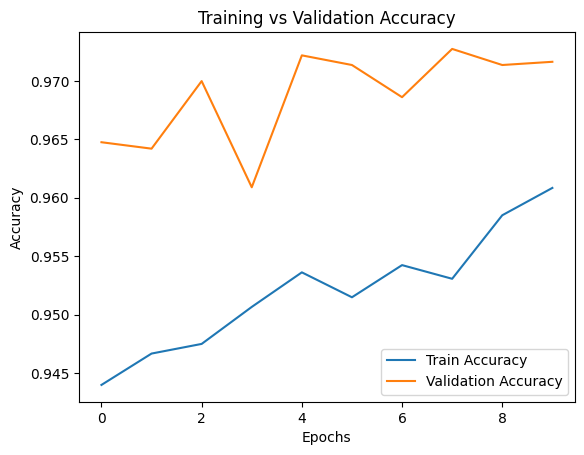

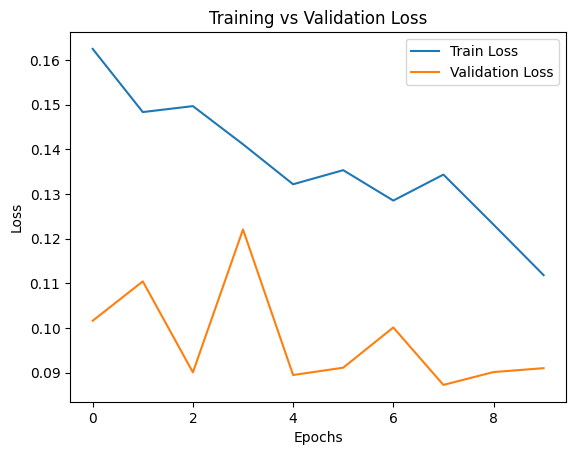

In [19]:
import matplotlib.pyplot as plt

plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

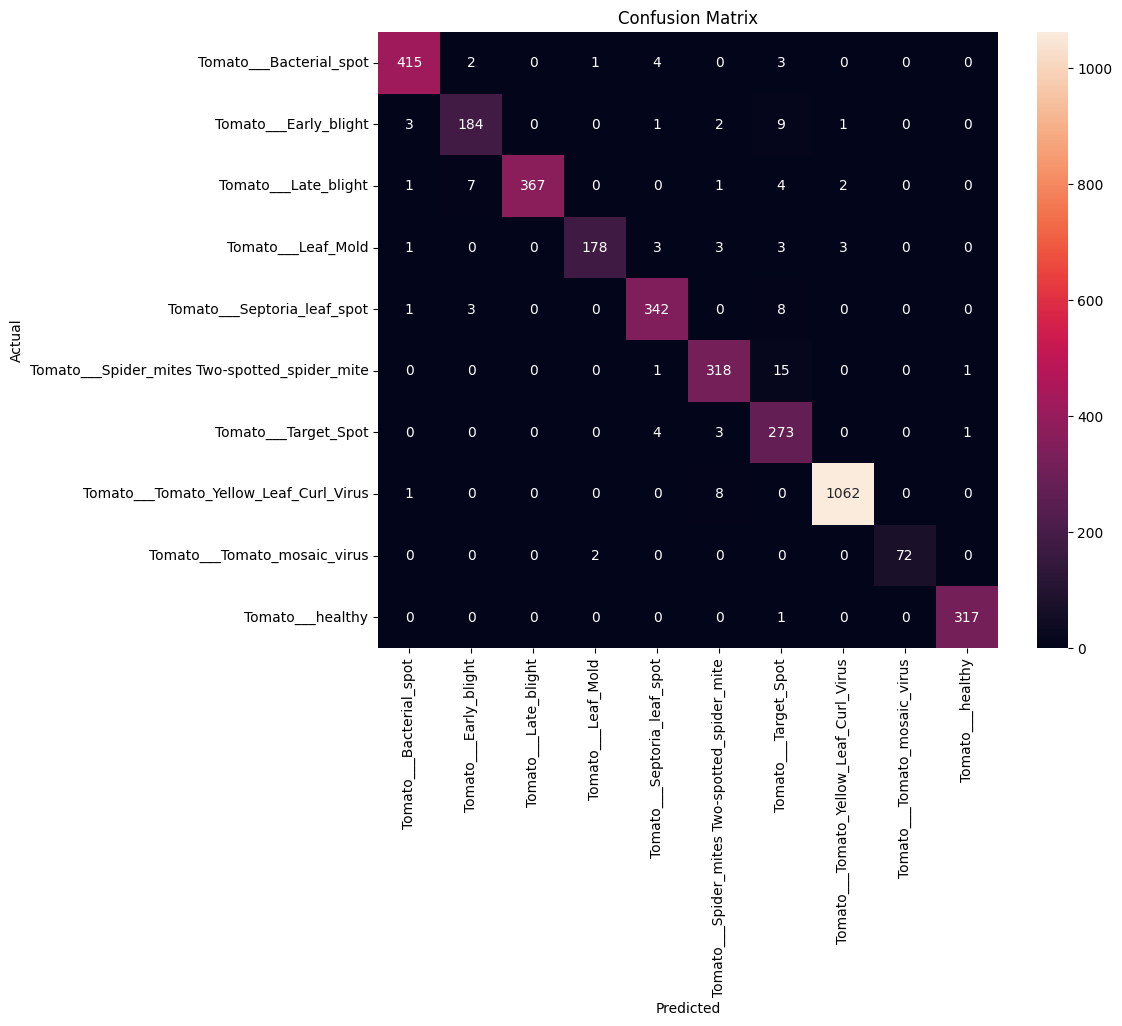

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.98      0.98       425
                        Tomato___Early_blight       0.94      0.92      0.93       200
                         Tomato___Late_blight       1.00      0.96      0.98       382
                           Tomato___Leaf_Mold       0.98      0.93      0.96       191
                  Tomato___Septoria_leaf_spot       0.96      0.97      0.96       354
Tomato___Spider_mites Two-spotted_spider_mite       0.95      0.95      0.95       335
                         Tomato___Target_Spot       0.86      0.97      0.91       281
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.99      0.99      1071
                 Tomato___Tomato_mosaic_virus       1.00      0.97      0.99        74
                             Tomato___healthy       0.99      1.00      1.00       318

                                     accu

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_eff.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [21]:
model_eff.save("tomato_model.h5")

In [22]:
model_eff.save("/content/drive/MyDrive/tomato_model.h5")